<a href="https://colab.research.google.com/github/chanu-24/BMW-CAR-COMPUTER-VISION/blob/main/Day3_Color_Masking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🚗 1. 원본 BMW


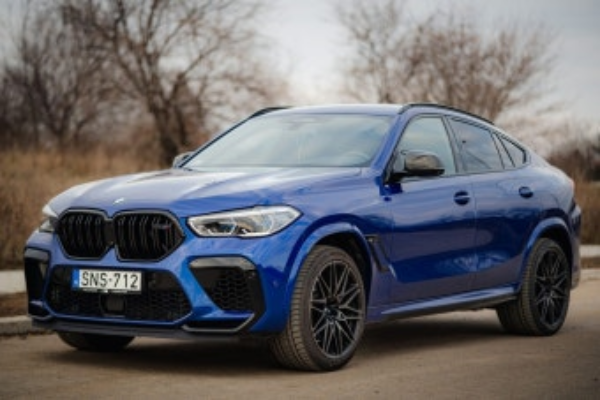


🎯 2. 파란색 스캔 완료! (엠블럼, 번호판 파란 줄, 차체 블루 등)


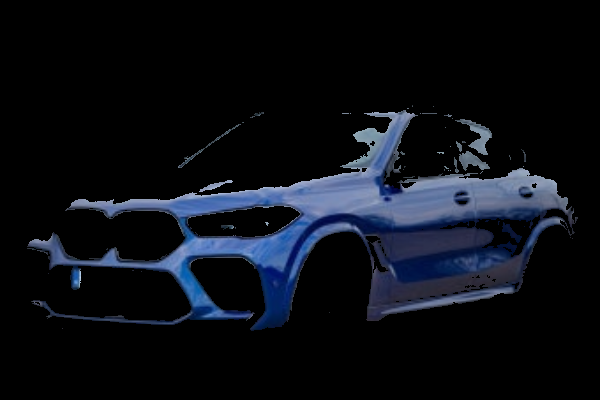

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

file_name='my_bmw.jpg'
img=cv2.imread(file_name)

if img is None:
  print(f"X'{file_name}' 파일이 없습니다. 어제처럼 왼쪽 폴터에 올려주세요")

else:
  img_resized=cv2.resize(img,(600,400))



  # 💡 [핵심 1] RGB를 AI가 좋아하는 HSV로 변환!


  hsv_img=cv2.cvtColor(img_resized,cv2.COLOR_BGR2HSV)
  # 💡 [핵심 2] 파란색(Blue)의 비밀번호(범위) 설정
  # OpenCV에서 파란색의 Hue(H)는 대략 100 ~ 140 사이입니다.

  lower_blue=np.array([100,50,50])
  upper_blue=np.array([140,255,255])

  # 💡 [핵심 3] 마스크(Mask) 씌우기: 파란색만 하얗게, 나머지는 까맣게 칠해!

  mask=cv2.inRange(hsv_img,lower_blue,upper_blue)

  result=cv2.bitwise_and(img_resized,img_resized,mask=mask)


  print("\n🚗 1. 원본 BMW")
  cv2_imshow(img_resized)


  print("\n🎯 2. 파란색 스캔 완료! (엠블럼, 번호판 파란 줄, 차체 블루 등)")
  cv2_imshow(result)








-지금까지 우리는 차의 색상을 다빼고
'키드니 그릴의 뼈대'만 남기는 법

-그런데 형태는 상관없고,BMW엠블럼만 찾는경우
-앞차의 빨간색 브레이크 등만 인식하고 싶어

-->자율주행 차간 거리 유지의 핵심,신호등을 인식하는 기술

*우리가 흔히 아는 RGB는 색을 찾기에 아주 끔찍한 방식

why? 왜나하면 햇빛이 강해지면 빨강,초록,파랑 숫자가 다같이 요동치기 떄문이다.

실무버전AI에서는 HSV라는 마법의 색상필터를 쓴다.

H(색상):순수한 색깔 그자체

S(채도):색이 얼마나 진한가?

v(명도):얼마나 밝은가?


-->이렇게 하면 그림자가 져서 명도(v)가 어두워도, 색상(H) 번호는 파란색 그대로 유지되기 떄문에 완벽하게 추적할수 있다.
